# Images and Convolutional Neural Networks

* Images -> Pixels -> Picture elements

* Each pixel contains color information

* In this section, we will use the Kaggle [Cloud Photos dataset](https://www.kaggle.com/datasets/jockeroika/clouds-photos/data), acknowledging the authors and contributors. 

* Check out the ```clouds_train``` and ```clouds_test``` folder structure in the ```data``` folder and the docs for ```ImageFolder``` function.

* Torchvision: Officially computer vision library for PyTorch.

In [1]:
import torchvision, torch
print(f'PyTorch version: {torch.__version__}')
print(f'Torchvision version: {torchvision.__version__}')

PyTorch version: 2.8.0+cu128
Torchvision version: 0.23.0+cu128


In [25]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
import torchvision.transforms.functional as F
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt

### 0 - Show a cloud image example

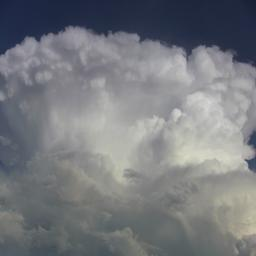

In [20]:
img_path = r'/home/devenv/Projects/deep-learning-with-pytorch/01-intermediate-dl/data/clouds_train/cumulonimbus clouds/c055e7211864fa6b07e07b87bb4ecbe4.jpg'
img = Image.open(img_path)
img.show()

### 1 - Define transformations

- Parse each image to Tensor
- Resize each image to 128 x 128

In [ ]:
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(45), # Data Augmentation
    transforms.ToTensor(),
    transforms.Resize(size=(128, 128))
])

### 2 - Image tranformed example

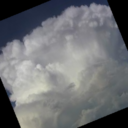

In [34]:
img_transformed = train_transforms(img)
img_pil = F.to_pil_image(img_transformed)
img_pil.show()

### 3 - Apply transformations.

Load images to PyTorch.

In [35]:
dataset_train = ImageFolder(
    root=r'/home/devenv/Projects/deep-learning-with-pytorch/01-intermediate-dl/data/clouds_train',
    transform=train_transforms
)

dataloader_train = DataLoader(
    dataset=dataset_train,
    shuffle=True,
    batch_size=1
)

Data sample.

In [39]:
image, label = next(iter(dataloader_train))
print(image.shape)
print(label)

# 1 for batch size of 1
# 3 for the three color channels
# 128 by 128 pixels: height and width.

torch.Size([1, 3, 128, 128])
tensor([4])


To displya a color images like this, it must be rearrange so the height and width come before the channels.

torch.Size([128, 128, 3])


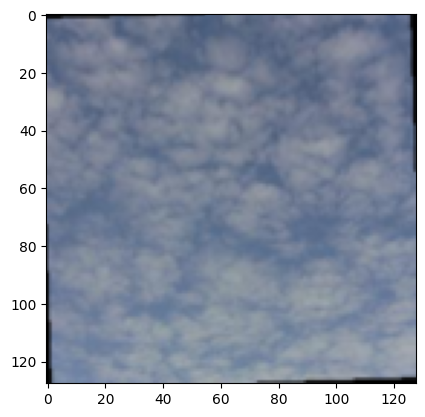

In [40]:
image = image.squeeze().permute(1, 2, 0)
print(image.shape)
plt.imshow(image)
plt.show()

Adding random transformations to the original images is a common technique know as **data augmentation**.

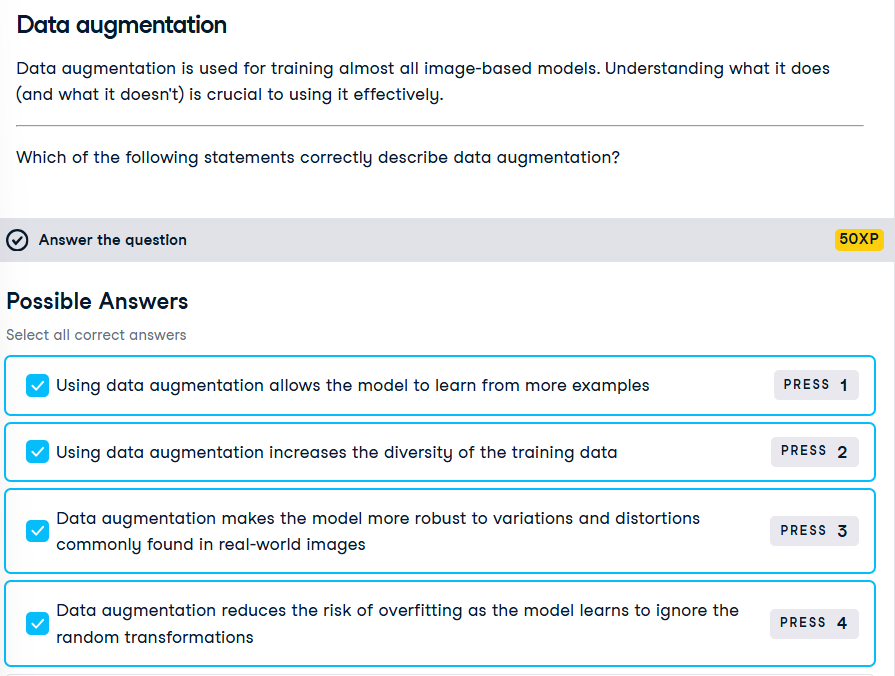

### 4 - Convolutional Neural Networks